In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

Random Seed

In [ ]:
random.seed(123)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/MLBookCamp/CarPrice/data.csv")

In [ ]:
len(df)

11914

In [ ]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


column names and some feature values have a mix of "-" and spaces

want to make sure everything is in the same capitalization

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ","_") #replace space with underscores

string_columns = list(df.dtypes[df.dtypes== "object"].index) #select cols with string values

for col in string_columns:
  df[col] = df[col].str.lower().str.replace(" ","_")

In [ ]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


Examine y, the MSRP or price

Check the distributsion

Check for missing values

<Axes: xlabel='msrp', ylabel='Count'>

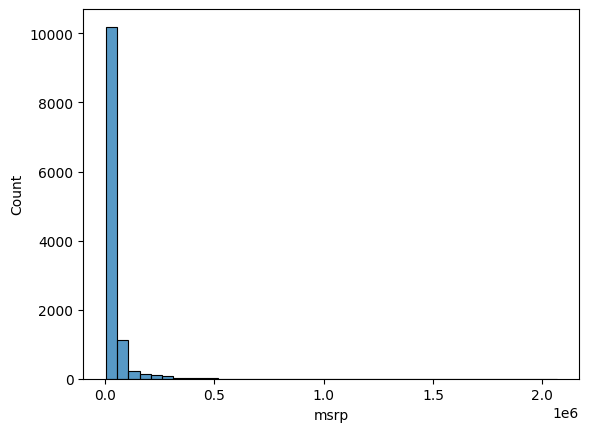

In [ ]:
sns.histplot(df.msrp, bins=40)


#long tail on this plot indicating few cars with high MSRP

<Axes: xlabel='msrp', ylabel='Count'>

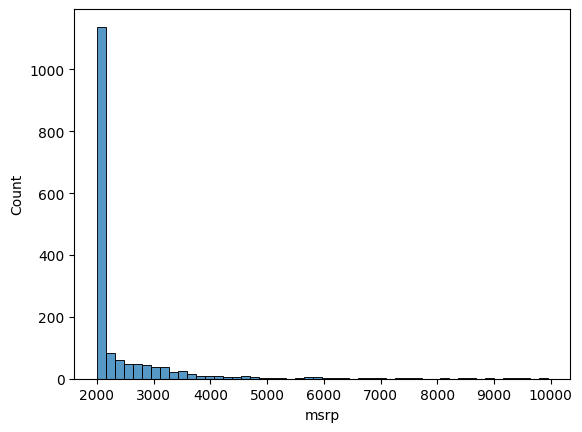

In [ ]:
#zoom in to msrp values < 10k

sns.histplot(df[df.msrp<10000].msrp, bins=50)


In [ ]:
#log transform the MSRP

log_price = np.log1p(df.msrp)

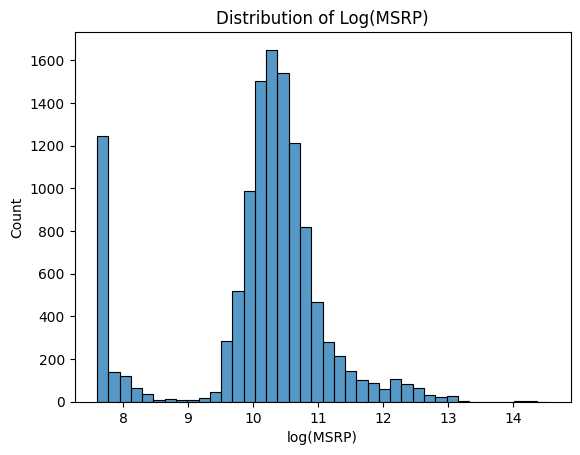

In [ ]:
#check distribution of log transformed MSRP
sns.histplot(log_price, bins = 40)
plt.xlabel("log(MSRP)")
plt.title("Distribution of Log(MSRP)")
plt.show()

Remember linear regression models work well on normally distributed data

In [ ]:
#check for missing values

df.isna().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


In [ ]:
#split the data set into train (60%), validation (20%), and test (20%)

#get the total number of rows

n = len(df)

#take 20% of data for validation
n_val = int(0.2*n)

#take 20% of data for test
n_test = int(0.2*n)

#subtract n_val and n_test from n to get the remaining 60% for training data
n_train = n - (n_val + n_test)

#random seed done at the top of notebook

idx = np.arange(n)
#create randomly shuffled np array
np.random.shuffle(idx)

#random shuffle df
df_shuffled = df.iloc[idx]

#create train, val, and test dfs from df_shuffle
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()


In [ ]:
#log transform all MSPR values of dfs

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)


In [ ]:
#delete the y values in the dfs so we don't accidentally use it later

del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]

Define Model

In [ ]:
#now code the linear regression function


#code dot product
def dot(xi, w):
  n = len(w)
  result = 0.0
  for j in range(n):
    result - result +xi[j] * w[j]
  return result



def linear_regression(xi):
  xi =[1] +xi
  return dot(xi,w)


Train Model

In [ ]:
#write training function

def train_linear_regression(X, y):
  #add dummy col
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])  #adds dummy col as the first col of X

  #normal equation forumla
  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w = XTX_inv.dot(X.T).dot(y)

  return w[0], w[1:] #splite the weights vector into the bias and the rest of the weights

Predict

In [ ]:
#Select features

base = ["engine_hp", "engine_cylinders", "highway_mpg", "city_mpg", "popularity"]

df_num = df_train[base]

In [ ]:
#if features have missing values fill with 0s
#features with 0 will have no contribution to the final prediction

df_num =df_num.fillna(0)

In [ ]:
#convert df to np array

X_train = df_num.values

In [ ]:
#train

w_0, w = train_linear_regression(X_train,y_train)

In [ ]:
#predict

y_pred = w_0 + X_train.dot(w)

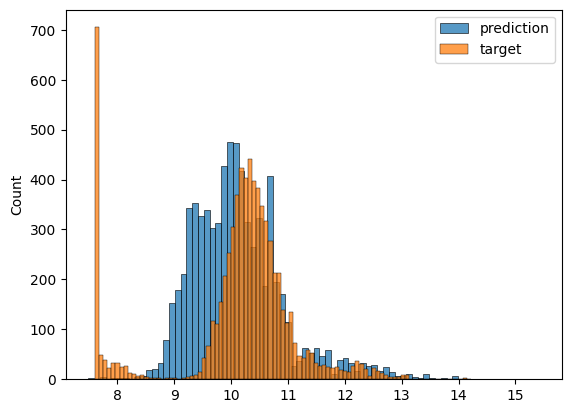

In [ ]:
#plot prediction values on historgram and compare with actual prices

sns.histplot(y_pred, label="prediction")
sns.histplot(y_train, label = "target")
plt.legend()
plt.show()


#note the discrepancy in between the prediction and target distributions
#this is due to the simplicity of the model

Evaluate Model Quality

In [ ]:
#use RMSE to evaluate model quality

def rmse(y, y_pred):
  error = y_pred -y
  mse = (error **2).mean()
  return np.sqrt(mse)

In [ ]:
rmse(y_train, y_pred)

np.float64(0.7524522974469755)

In [ ]:
#when comparing RMSE, the model with the lowest RMSE is the better performing model

Validating the model